# 5. Respiration & RSA (Principles: vagal brake, cardiorespiratory coupling)

1. PAPERS: [Sensing Systems for Respiration Monitoring:
A Technical Systematic Review](https://github.com/roeh-health/lamina/blob/general_wesad_analysis/papers/sensingSystemsForRespirationMonitoringTechnicalSystematicReview.pdf)

2. See Figma

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import neurokit2 as nk

import matplotlib.pyplot as plt

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../../signal'))

from data_processing import DataProcessing

In [2]:
respiration_frequency_sampling_rate = 700

## Load Data

In [3]:
data_path = "../../../data/WESAD/all_subjects/chest.csv"
df = DataProcessing.load_chest_df(base_dir=notebook_dir, file_type='.csv', path_to_file=data_path)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


## Get Specific Subject + Health Measure of Interest

In [4]:
## Option 1: Get s_id from .get_per_subject_dict()
s_id = 'S7'

per_subject_dfs, s_df = DataProcessing.get_data_per_subject(df, s_id)


### Option 2: Get s_id from per_subject_dfs
# s_df = per_subject_dfs[s_id]

### Option 3: Get s_id from per_subject_dfs
# s_id = 'None'

# per_subject_dfs = DataProcessing.get_per_subject_dict(df, s_id)
# print(per_subject_dfs)

# s3_id = 'S3'
# s3_df = DataProcessing.get_specific_subject_df(per_subject_dfs, s3_id)

In [5]:
s_df

,index,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,22626800,1.0696,-0.0140,1.4612,-0.019226,-0.048843,12.506866,33.993530,1.832581,S7,0
1,22626801,1.0654,-0.0102,1.4222,-0.016937,-0.007004,12.468719,33.932680,1.835632,S7,0
2,22626802,1.0654,0.0042,1.3202,-0.016159,0.071777,12.506866,33.970703,1.856995,S7,0
3,22626803,1.0666,0.0202,1.1464,-0.012405,0.088486,12.506485,34.008760,1.829529,S7,0
4,22626804,1.0602,0.0310,0.9192,-0.020325,0.090271,12.504959,33.887085,1.817322,S7,0
...,...,...,...,...,...,...,...,...,...,...,...
3666595,26293395,0.8586,-0.0958,-0.0390,0.156418,-0.036942,13.085556,34.917084,0.813293,S7,0
3666596,26293396,0.8526,-0.1026,-0.0430,0.115723,0.098831,13.089371,34.935608,0.816345,S7,0
3666597,26293397,0.8466,-0.1082,-0.0574,0.086380,0.199768,13.090134,34.943300,0.804138,S7,0
3666598,26293398,0.8422,-0.1138,-0.0814,0.139938,0.227646,13.081360,34.940247,0.834656,S7,0


In [6]:
health_measure_name = 'Resp'

In [7]:
resp_df = DataProcessing.get_specific_health_measure_df(s_df, health_measure_name)
resp_df

,Resp
0,1.832581
1,1.835632
2,1.856995
3,1.829529
4,1.817322
...,...
3666595,0.813293
3666596,0.816345
3666597,0.804138
3666598,0.834656


## Create Time Component

In [8]:
DataProcessing.create_time_df(resp_df, respiration_frequency_sampling_rate)
# resp_df.set_index(["Seconds"])

,Resp,Milliseconds,Seconds,Time
0,1.832581,0.00,0.00,0 days 00:00:00
1,1.835632,1.43,0.00,0 days 00:00:00
2,1.856995,2.86,0.00,0 days 00:00:00
3,1.829529,4.29,0.00,0 days 00:00:00
4,1.817322,5.71,0.01,0 days 00:00:00.010000
...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18


In [9]:
one_minute = 60
filt_one_minute = resp_df['Seconds'] <= one_minute
filt_one_minute

0           True
1           True
2           True
3           True
4           True
           ...  
3666595    False
3666596    False
3666597    False
3666598    False
3666599    False
Name: Seconds, Length: 3666600, dtype: bool

In [10]:
m_minutes = 3
M_seconds = one_minute * m_minutes
M_minutes_df = resp_df['Seconds'] <= M_seconds
M_minutes_df

0           True
1           True
2           True
3           True
4           True
           ...  
3666595    False
3666596    False
3666597    False
3666598    False
3666599    False
Name: Seconds, Length: 3666600, dtype: bool

### Visualize Raw Data

<Axes: title={'center': '3 Minutes = 180 Seconds'}, xlabel='Seconds'>

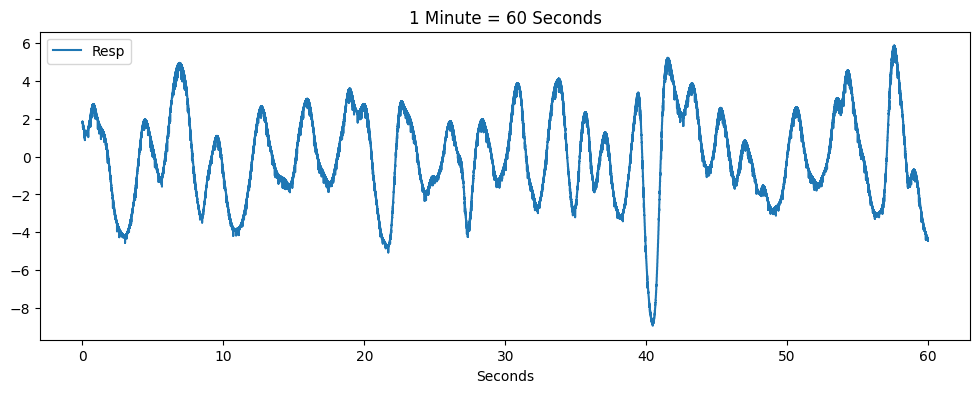

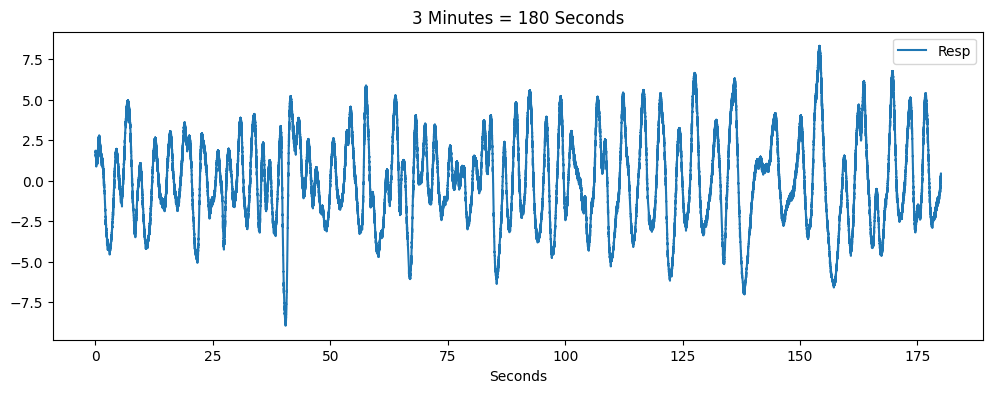

In [11]:
resp_df[filt_one_minute].plot.line(x='Seconds', y=health_measure_name, figsize=(12, 4), title=f'1 Minute = {one_minute} Seconds')
resp_df[M_minutes_df].plot.line(x='Seconds', y=health_measure_name, figsize=(12, 4), title=f'{m_minutes} Minutes = {M_seconds} Seconds')

## Clean Data

In [12]:
clean_col_name = "Cleaned Resp"
resp_df[clean_col_name] = nk.rsp_clean(resp_df[health_measure_name])
resp_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394
...,...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000,-0.001080
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000,-0.000927
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18,-0.000788
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18,-0.000663


### Visualize Cleaned Data

+ [x] Need to properly align time and plots

<Axes: title={'center': '3 Minutes = 180 Seconds'}, xlabel='Seconds'>

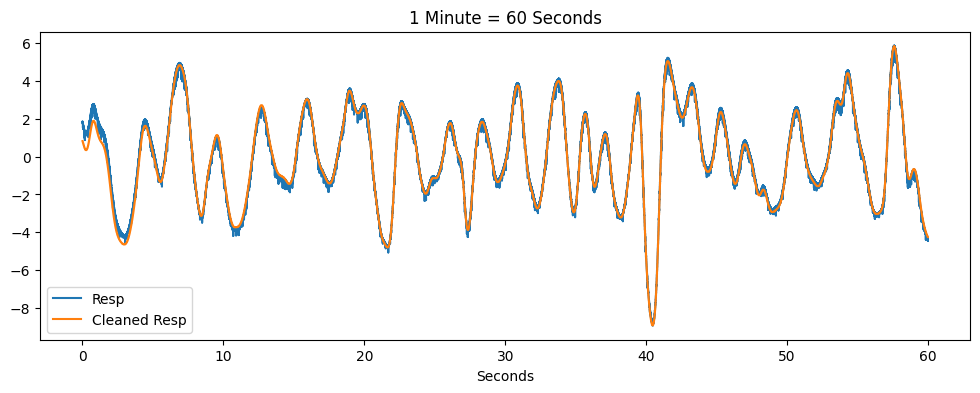

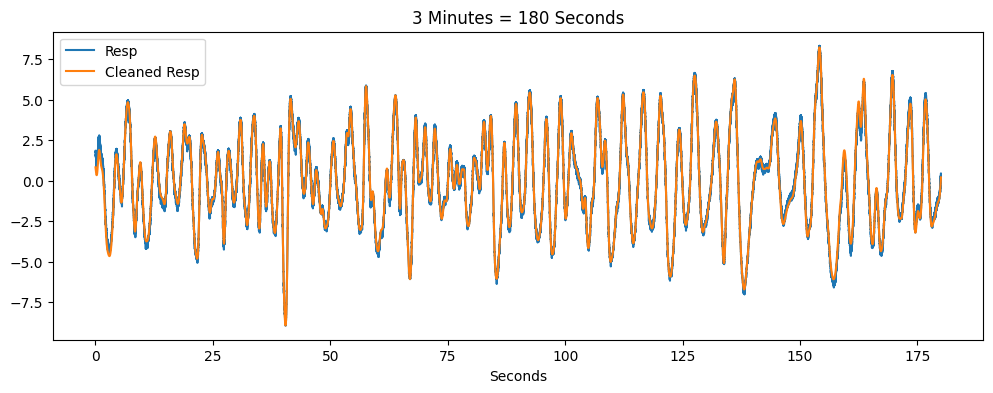

In [13]:
resp_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'1 Minute = {one_minute} Seconds')
resp_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'{m_minutes} Minutes = {M_seconds} Seconds')

## Get Peaks

In [14]:
peak_signal, info = nk.rsp_peaks(resp_df[clean_col_name], sampling_rate=respiration_frequency_sampling_rate)
peak_signal

,RSP_Peaks,RSP_Troughs
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
3666595,0,0
3666596,0,0
3666597,0,0
3666598,0,0


### Align Peaks and Troughs to Resp DF

In [15]:
resp_df = pd.concat([resp_df, peak_signal], axis=1)
resp_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737,0,0
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691,0,0
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619,0,0
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520,0,0
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394,0,0
...,...,...,...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000,-0.001080,0,0
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000,-0.000927,0,0
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18,-0.000788,0,0
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18,-0.000663,0,0


### Filt either Peaks or Troughs

In [16]:
def filt_data(df, col_name, col_value):
    filt = (df[col_name] == col_value)
    return df[filt]

resp_peaks_df = filt_data(resp_df, 'RSP_Peaks', 1)
resp_peaks_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs
3114,1.945496,4448.57,4.45,0 days 00:00:04.450000,1.633594,1,0
4825,4.898071,6892.86,6.89,0 days 00:00:06.890000,4.845272,1,0
6681,1.094055,9544.29,9.54,0 days 00:00:09.540000,1.146237,1,0
8894,2.545166,12705.71,12.71,0 days 00:00:12.710000,2.724443,1,0
11157,3.044128,15938.57,15.94,0 days 00:00:15.940000,3.045227,1,0
...,...,...,...,...,...,...,...
3655172,2.507019,5221674.29,5221.67,0 days 01:27:01.670000,2.346274,1,0
3656577,1.167297,5223681.43,5223.68,0 days 01:27:03.680000,1.088422,1,0
3657891,5.207825,5225558.57,5225.56,0 days 01:27:05.560000,5.239702,1,0
3659157,1.704407,5227367.14,5227.37,0 days 01:27:07.370000,1.759624,1,0


In [17]:
resp_troughs_df = filt_data(resp_df, 'RSP_Troughs', 1)
resp_troughs_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs
2079,-4.173279,2970.00,2.97,0 days 00:00:02.970000,-4.649757,0,1
3875,-1.210022,5535.71,5.54,0 days 00:00:05.540000,-1.344089,0,1
5900,-3.208923,8428.57,8.43,0 days 00:00:08.430000,-3.138074,0,1
7603,-3.837585,10861.43,10.86,0 days 00:00:10.860000,-3.744520,0,1
10275,-1.507568,14678.57,14.68,0 days 00:00:14.680000,-1.445693,0,1
...,...,...,...,...,...,...,...
3653197,-1.248169,5218852.86,5218.85,0 days 01:26:58.850000,-1.447488,0,1
3655810,-2.589417,5222585.71,5222.59,0 days 01:27:02.590000,-2.712099,0,1
3657175,-0.950623,5224535.71,5224.54,0 days 01:27:04.540000,-0.992612,0,1
3658609,-7.655334,5226584.29,5226.58,0 days 01:27:06.580000,-7.608902,0,1


### Plot Peaks and Troughs

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/3561512417.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  resp_peaks_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Peaks: 1 Minute = {one_minute} Seconds')
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/3561512417.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  resp_peaks_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Peaks: {m_minutes} Minutes = {M_seconds} Seconds')
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/3561512417.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  resp_troughs_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Troughs: 1 Minute = {one_minute} Seconds')
/var/folders/78/9z0b45fx1xqbw

<Axes: title={'center': 'Troughs: 3 Minutes = 180 Seconds'}, xlabel='Seconds'>

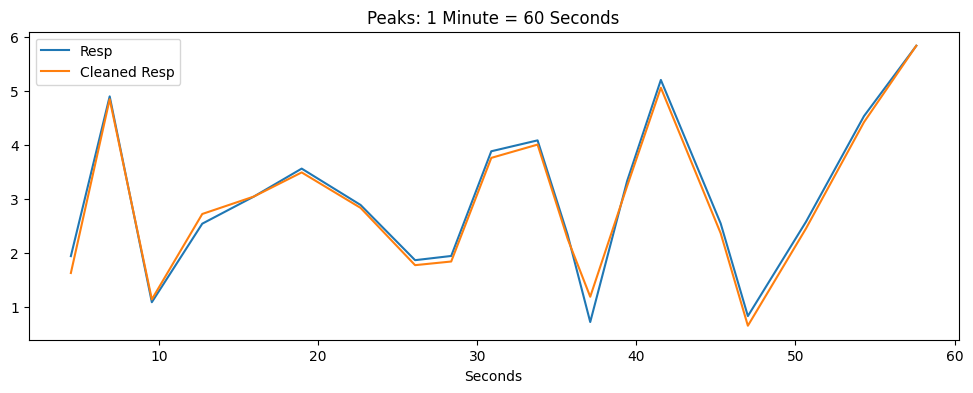

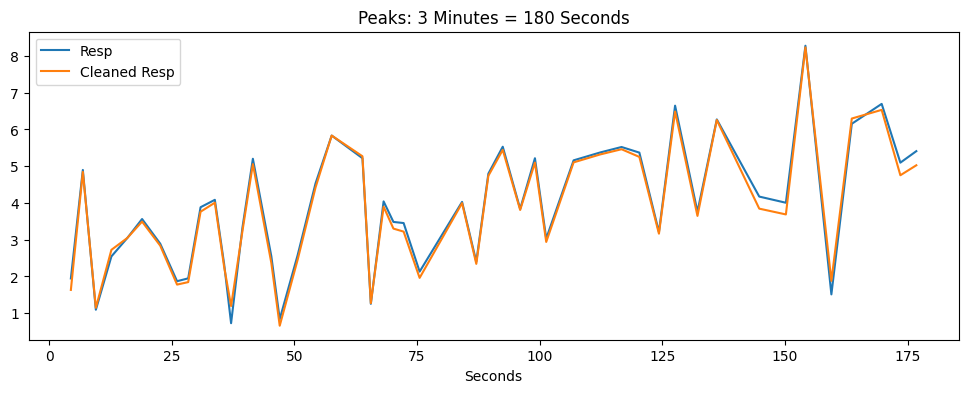

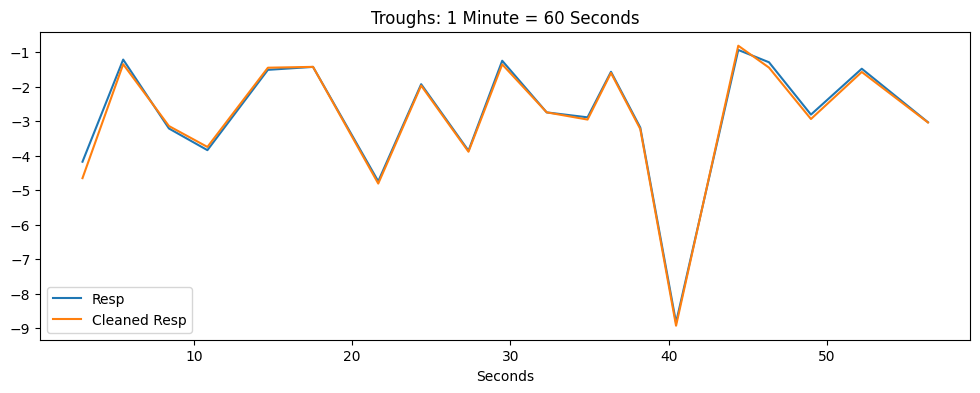

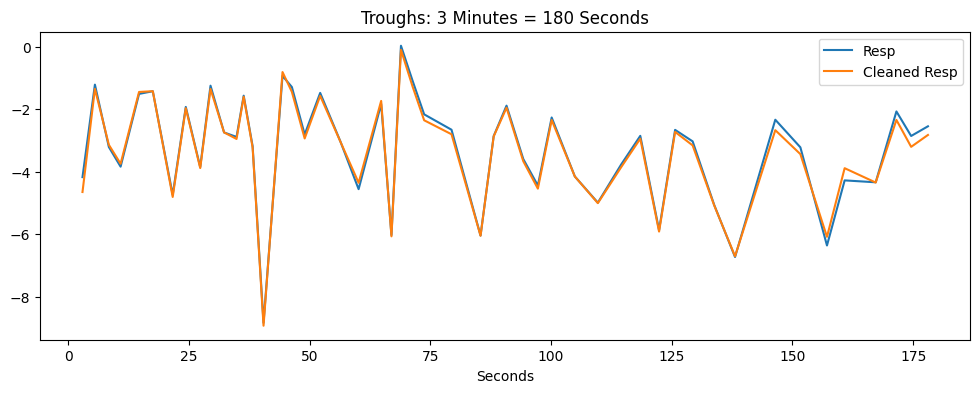

In [18]:
resp_peaks_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Peaks: 1 Minute = {one_minute} Seconds')
resp_peaks_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Peaks: {m_minutes} Minutes = {M_seconds} Seconds')


resp_troughs_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Troughs: 1 Minute = {one_minute} Seconds')
resp_troughs_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Troughs: {m_minutes} Minutes = {M_seconds} Seconds')

## Get Stats

In [19]:
def get_stats(df, col_name):
    return {
        'Min': df[col_name].min(),
        'Max': df[col_name].max(),
        'Range': df[col_name].max() - df[col_name].min(),
        'Mean': df[col_name].mean(),
        'Median': df[col_name].median(),
        'Std': df[col_name].std()
    }

In [20]:
resp_peaks_stats = get_stats(resp_peaks_df, clean_col_name)
resp_peaks_stats

{'Min': np.float64(0.16823393614490648),
 'Max': np.float64(33.71574530738188),
 'Range': np.float64(33.54751137123697),
 'Mean': np.float64(4.571989702619084),
 'Median': np.float64(4.007603463519107),
 'Std': np.float64(2.863669211092623)}

In [21]:
resp_troughs_stats = get_stats(resp_troughs_df, clean_col_name)
resp_troughs_stats

{'Min': np.float64(-39.18543362953222),
 'Max': np.float64(-0.006226365941876311),
 'Range': np.float64(39.17920726359034),
 'Mean': np.float64(-3.8580929020919728),
 'Median': np.float64(-2.9560824067405767),
 'Std': np.float64(3.5414428486808696)}

## Get Segments

In [ ]:
segments_df, segments_groupby_df = DataProcessing.get_segments_by_duration(resp_df, window_size_sec=300)
segments_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs,window_id,window_start_seconds,window_end_seconds
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737,0,0,0,0,300
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691,0,0,0,0,300
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619,0,0,0,0,300
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520,0,0,0,0,300
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394,0,0,0,0,300
...,...,...,...,...,...,...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000,-0.001080,0,0,17,5100,5400
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000,-0.000927,0,0,17,5100,5400
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18,-0.000788,0,0,17,5100,5400
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18,-0.000663,0,0,17,5100,5400


In [23]:
zero_segment_df = filt_data(segments_df, 'window_id', 0)
zero_segment_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs,window_id,window_start_seconds,window_end_seconds
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737,0,0,0,0,300
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691,0,0,0,0,300
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619,0,0,0,0,300
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520,0,0,0,0,300
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394,0,0,0,0,300
...,...,...,...,...,...,...,...,...,...,...
209992,-0.621033,299988.57,299.99,0 days 00:04:59.990000,-0.734457,0,0,0,0,300
209993,-0.627136,299990.00,299.99,0 days 00:04:59.990000,-0.743325,0,0,0,0,300
209994,-0.636292,299991.43,299.99,0 days 00:04:59.990000,-0.752177,0,0,0,0,300
209995,-0.648499,299992.86,299.99,0 days 00:04:59.990000,-0.761012,0,0,0,0,300


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/702399360.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  zero_segment_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 1 Minute = {one_minute} Seconds')
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/702399360.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  zero_segment_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): {m_minutes} Minutes = {M_seconds} Seconds')


<Axes: title={'center': 'Segment (0): 5 Minutes = 300 Seconds'}, xlabel='Seconds'>

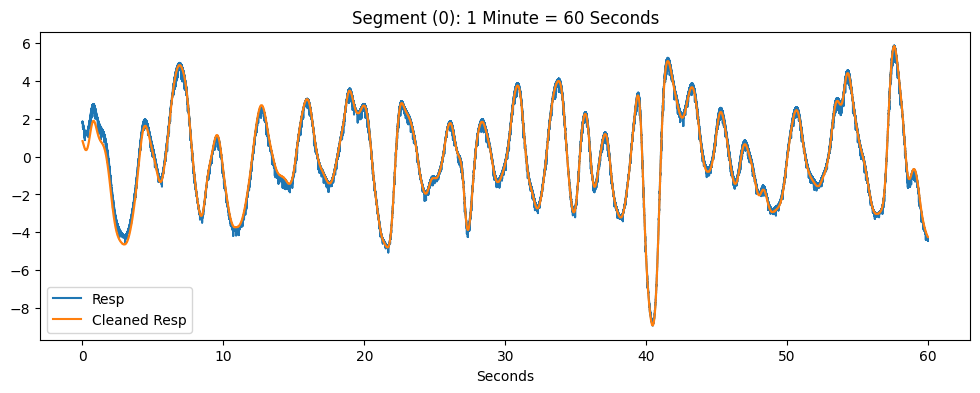

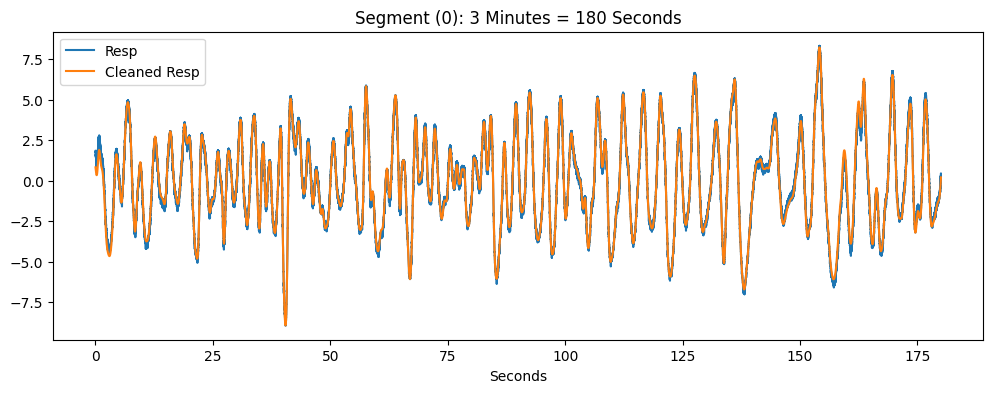

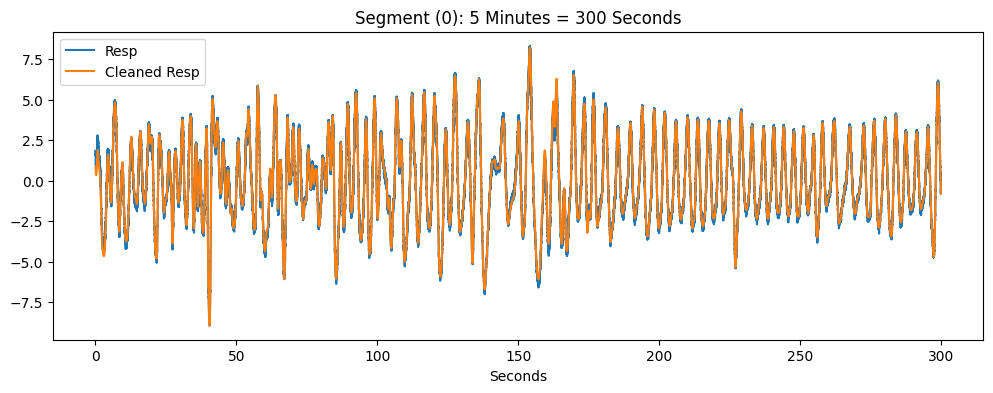

In [24]:
zero_segment_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 1 Minute = {one_minute} Seconds')
zero_segment_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): {m_minutes} Minutes = {M_seconds} Seconds')
zero_segment_df.plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 5 Minutes = 300 Seconds')

## Metrics: Respiratory and Volume Parameters

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/2240910838.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  zero_segment_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 1 Minute = {one_minute} Seconds')


<Axes: title={'center': 'Segment (0): 1 Minute = 60 Seconds'}, xlabel='Seconds'>

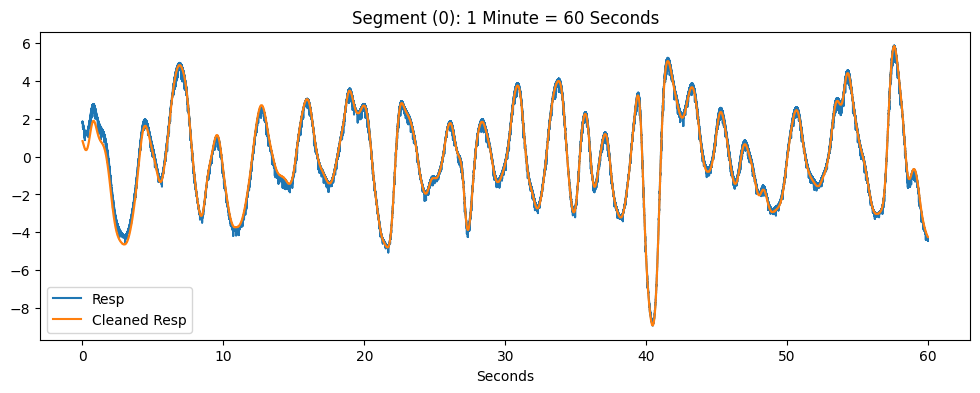

In [25]:
zero_segment_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 1 Minute = {one_minute} Seconds')


In [26]:
filt_secs = zero_segment_df[filt_one_minute]['Seconds'].values < 10
zero_segment_df[filt_one_minute][filt_secs]

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/1178285010.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filt_secs = zero_segment_df[filt_one_minute]['Seconds'].values < 10
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/1178285010.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  zero_segment_df[filt_one_minute][filt_secs]


,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs,window_id,window_start_seconds,window_end_seconds
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737,0,0,0,0,300
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691,0,0,0,0,300
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619,0,0,0,0,300
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520,0,0,0,0,300
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394,0,0,0,0,300
...,...,...,...,...,...,...,...,...,...,...
6992,-0.837708,9988.57,9.99,0 days 00:00:09.990000,-0.711758,0,0,0,0,300
6993,-0.834656,9990.00,9.99,0 days 00:00:09.990000,-0.720575,0,0,0,0,300
6994,-0.828552,9991.43,9.99,0 days 00:00:09.990000,-0.729387,0,0,0,0,300
6995,-0.840759,9992.86,9.99,0 days 00:00:09.990000,-0.738193,0,0,0,0,300


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/3962571001.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  zero_segment_df[filt_one_minute][filt_secs].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 1 Minute = {one_minute} Seconds')


<Axes: title={'center': 'Segment (0): 1 Minute = 60 Seconds'}, xlabel='Seconds'>

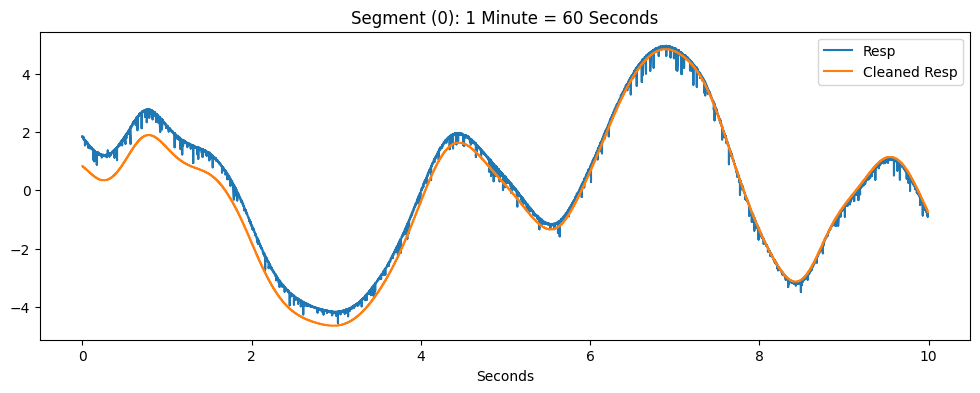

In [27]:
zero_segment_df[filt_one_minute][filt_secs].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'Segment (0): 1 Minute = {one_minute} Seconds')

### Breathing Period

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/2316451982.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x = zero_segment_df[filt_one_minute][filt_secs]['Seconds']
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/2316451982.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = zero_segment_df[filt_one_minute][filt_secs]['Cleaned Resp']


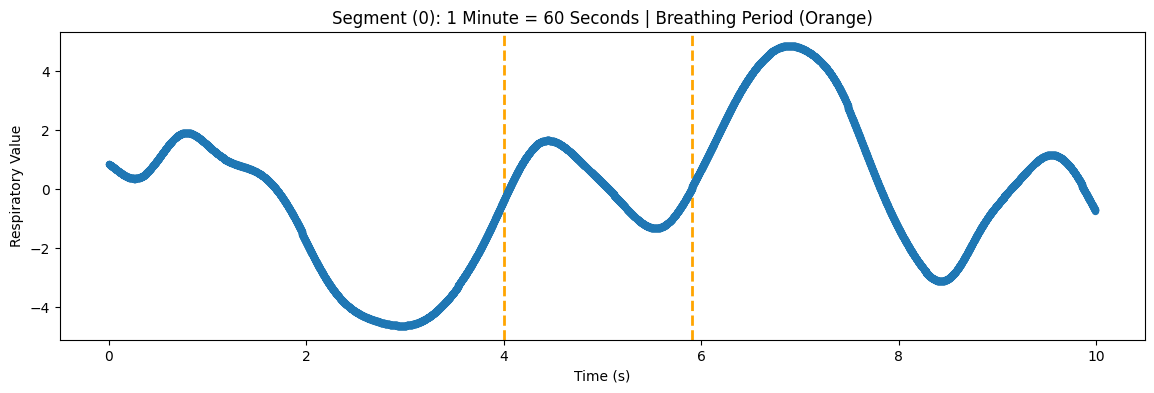

In [28]:
x = zero_segment_df[filt_one_minute][filt_secs]['Seconds']
y = zero_segment_df[filt_one_minute][filt_secs]['Cleaned Resp']
fig, ax = plt.subplots(figsize=(14, 4))

# ax.set_yticks(y)  # keep numbers on y-axis
ax.set_title(f'Segment (0): 1 Minute = {one_minute} Seconds | Breathing Period (Orange)')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Respiratory Value")
ax.scatter(x, y, s=18, color='tab:blue', zorder=3)

ax.axvline(x=4, color='orange', linestyle='--', linewidth=2, label='Marker at x=3')
ax.axvline(x=5.9, color='orange', linestyle='--', linewidth=2, label='Marker at x=3')

### Inspiratory Time

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/2846218855.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x = zero_segment_df[filt_one_minute][filt_secs]['Seconds']
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/2846218855.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = zero_segment_df[filt_one_minute][filt_secs]['Cleaned Resp']


Text(6.9, 1, '(V_b, t_b)')

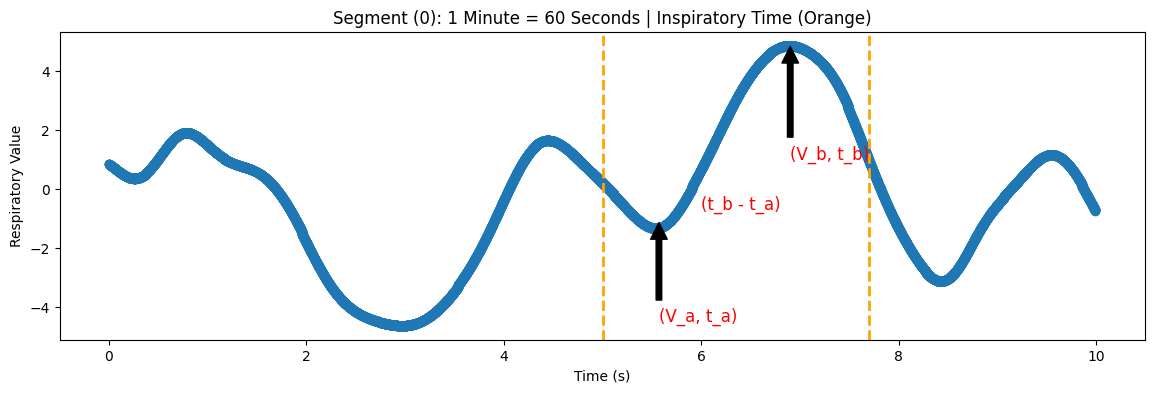

In [29]:
x = zero_segment_df[filt_one_minute][filt_secs]['Seconds']
y = zero_segment_df[filt_one_minute][filt_secs]['Cleaned Resp']
fig, ax = plt.subplots(figsize=(14, 4))

# ax.set_yticks(y)  # keep numbers on y-axis
ax.set_title(f'Segment (0): 1 Minute = {one_minute} Seconds | Inspiratory Time (Orange)')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Respiratory Value")
ax.scatter(x, y, color='tab:blue')

ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Marker at x=3')
ax.axvline(x=7.7, color='orange', linestyle='--', linewidth=2, label='Marker at x=3')

plt.annotate('(V_a, t_a)',
            xy=(5.57, -1), xytext=(5.57, -4.5),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, color='red')
plt.annotate('(t_b - t_a)',
            xy=(5.57, -0.7), xytext=(6, -0.7),
            fontsize=12, color='red')
plt.annotate('(V_b, t_b)',
            xy=(6.9, 5), xytext=(6.9, 1),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, color='red')

### Expiratory Time

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/3887111529.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x = zero_segment_df[filt_one_minute][filt_secs]['Seconds']
/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_2010/3887111529.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = zero_segment_df[filt_one_minute][filt_secs]['Cleaned Resp']


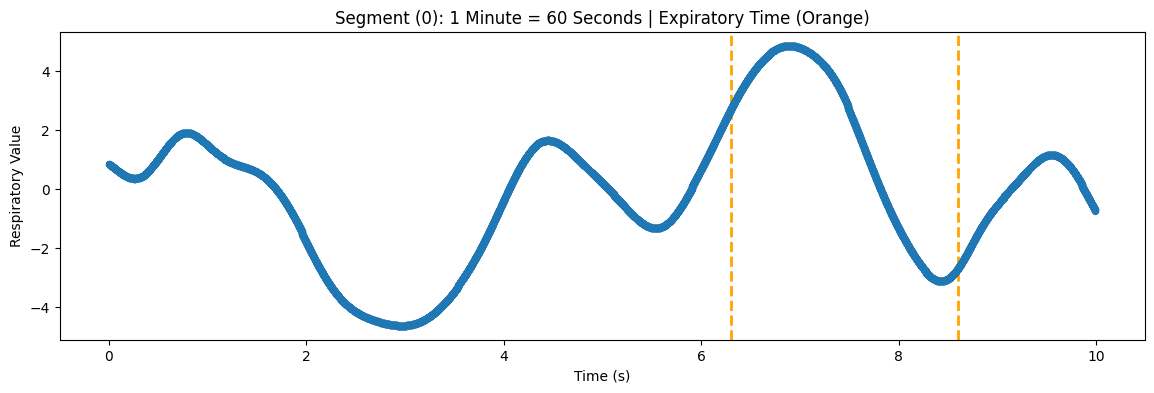

In [30]:
x = zero_segment_df[filt_one_minute][filt_secs]['Seconds']
y = zero_segment_df[filt_one_minute][filt_secs]['Cleaned Resp']
fig, ax = plt.subplots(figsize=(14, 4))

# ax.set_yticks(y)  # keep numbers on y-axis
ax.set_title(f'Segment (0): 1 Minute = {one_minute} Seconds | Expiratory Time (Orange)')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Respiratory Value")
ax.scatter(x, y, s=18, color='tab:blue', zorder=3)

ax.axvline(x=6.3, color='orange', linestyle='--', linewidth=2, label='Marker at x=3')
ax.axvline(x=8.6, color='orange', linestyle='--', linewidth=2, label='Marker at x=3')

In [36]:
filt_rsp_peaks = (zero_segment_df['RSP_Peaks'] == 1)
zero_segment_df[filt_rsp_peaks]

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,RSP_Peaks,RSP_Troughs,window_id,window_start_seconds,window_end_seconds
3114,1.945496,4448.57,4.45,0 days 00:00:04.450000,1.633594,1,0,0,0,300
4825,4.898071,6892.86,6.89,0 days 00:00:06.890000,4.845272,1,0,0,0,300
6681,1.094055,9544.29,9.54,0 days 00:00:09.540000,1.146237,1,0,0,0,300
8894,2.545166,12705.71,12.71,0 days 00:00:12.710000,2.724443,1,0,0,0,300
11157,3.044128,15938.57,15.94,0 days 00:00:15.940000,3.045227,1,0,0,0,300
...,...,...,...,...,...,...,...,...,...,...
198813,4.106140,284018.57,284.02,0 days 00:04:44.020000,4.053019,1,0,0,0,300
201281,3.086853,287544.29,287.54,0 days 00:04:47.540000,3.044722,1,0,0,0,300
204008,3.083801,291440.00,291.44,0 days 00:04:51.440000,3.025414,1,0,0,0,300
206788,3.404236,295411.43,295.41,0 days 00:04:55.410000,3.315102,1,0,0,0,300
